# **Data Kualitas Wine**

## **Business Understanding**

### Konteks

Dalam industri pembuatan wine, kualitas wine merupakan faktor utama yang menentukan kepuasan pelanggan dan daya saing di pasar. Kualitas wine dipengaruhi oleh berbagai parameter kimia seperti tingkat keasaman, kadar gula, kandungan alkohol, serta konsentrasi sulfur dioksida. Oleh karena itu, memahami hubungan antara karakteristik kimia wine dengan penilaian kualitas sangat penting bagi produsen untuk mengoptimalkan proses produksi dan menjaga konsistensi mutu produk.

Melalui analisis data, perusahaan atau produsen dapat memperoleh wawasan mengenai variabel-variabel mana yang paling berpengaruh terhadap penilaian kualitas. Pemahaman ini dapat menjadi dasar untuk melakukan perbaikan formula, pengendalian mutu, dan inovasi produk secara lebih terarah.

### Problem Statement

Produsen wine menghadapi tantangan dalam menjaga konsistensi kualitas setiap batch yang diproduksi. Penilaian kualitas wine selama ini sering kali dilakukan secara manual oleh ahli pengecap (wine tasters), yang bersifat subjektif dan memerlukan waktu serta biaya yang cukup besar.

Kondisi ini menimbulkan kesulitan dalam melakukan evaluasi cepat terhadap kualitas produk selama proses produksi berlangsung. Selain itu, tidak adanya sistem prediksi otomatis membuat perusahaan sulit mengantisipasi kemungkinan terjadinya penurunan mutu sebelum produk sampai ke tahap akhir.

In [2289]:
#Import library pandas
import pandas as pd

#Import library numpy
import numpy as np

#import library matplotloib dan seaborn untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

#me-non aktifkan peringatan pada phyton
import warnings
warnings.filterwarnings('ignore')

# Import joblib untuk menyimpan model
import joblib

### Tujuan

Penelitian ini bertujuan untuk mengembangkan model prediksi kualitas wine berdasarkan karakteristik kimia yang dimilikinya. Model tersebut diharapkan mampu:


1.   Mengidentifikasi faktor-faktor utama yang memengaruhi kualitas wine.
2.   Memprediksi tingkat kualitas wine secara otomatis dengan akurasi yang tinggi.
3.   Membantu perusahaan dalam pengendalian mutu dan peningkatan efisiensi proses produksi.








## **Data Understanding**
Sebelum melakukan tahapan analisis data, perlu dilakukan pemahaman dataset secara mendalam, serta identifikasi dataset yang mengalami missing value, sehingga perlu dilakukan perbaikan pada dataset. Setiap langkah yang diambil untuk mengatasi terjadinya missing value akan didukung oleh penjelasan secara empiris dan kuat, serta pendekatan analisis statistik. Pada tahap ini ada beberapa hal yang akan kita lakukan yakni:
1. menampilkan informasi yang ada di dataset berupa jumlah kolom, jumlah baris dan datatype dari dataset tersebut.
2. melihat pada datset apakah ada data yang kosong (null/NaN), jika ada maka akan kita atasi bergantung pada kondisi data tersebut.
3. melihat dekripsi dari dataset yang kita miliki (nilai yang paling sering muncul, standard deviasi, mean, median, dll)
4. melihat apakah data ada indikasi imbalance atau tidak
5. melihat pada dataset apakah ada *outlier*
6. *Predictor Feature* yaitu melihat variabel-variabel mana yang dapat menjadi variabel prediktor yang baik.

### Panggil file

In [2290]:
dataset = "/content/data_training.csv"
training = pd.read_csv(dataset, sep=';')

display (training.head())
print (f'Jumlah baris dan kolom di dataset kualitas wine adalah {training.shape}')
print(training.info())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,100.01200,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


Jumlah baris dan kolom di dataset kualitas wine adalah (857, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    object 
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(10), int64(2), object(1)
memory usage: 87.2+ KB
N

Data tersebut merupakan data yang menggambarkan data kualitas wine. Dataset terdiri dari 857 baris dengan 13 kolom. Berikut adalah variabel-variabel yang terdapat dalam dataset:


1. Keasaman tetap (fixed acidity)
2. Keasaman mudah menguap (volatile acidity)
3. Asam sitrat (citric acid
4. Kadar gula sisa (residual sugar)
5. Kadar klorida (chlorides)
6. Sulfur dioksida bebas (free sulfur dioxide)
7. Sulfur dioksida total (total sulfur dioxide)
8. Kerapatan cairan (density)
9. Derajat keasaman (pH)
10. Kandungan sulfat (sulphates)
11. Kadar alkohol (alcohol)
12. Kualitas wine (quality)

Dataset yang digunakan berisi data hasil pengujian laboratorium terhadap berbagai sampel wine. Setiap baris dalam dataset merepresentasikan satu sampel wine yang telah diuji, sedangkan setiap kolom menunjukkan nilai dari karakteristik kimia tertentu yang dapat memengaruhi penilaian kualitas.

Secara umum, data ini terdiri dari 11 variabel input (fitur) dan 1 variabel target, yaitu quality, yang menunjukkan tingkat kualitas wine berdasarkan penilaian ahli dalam skala numerik. Variabel-variabel input menggambarkan aspek-aspek kimiawi wine seperti tingkat keasaman, kadar gula, kandungan alkohol, serta konsentrasi sulfur dioksida.

Pemahaman terhadap distribusi, korelasi, serta pola dari setiap variabel ini menjadi dasar penting dalam tahap analisis selanjutnya. Dengan memahami struktur dan karakteristik data secara menyeluruh, kita dapat menentukan strategi pemodelan yang paling sesuai untuk memprediksi kualitas wine secara akurat.

Berikut merupakan lima baris pertama dan terakhir dari dataset kualitas wine:


In [2291]:
training

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,100.01200,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918
...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,6.7,1.040,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0,4,1467
853,8.0,0.390,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0,5,1533
854,7.4,0.350,0.33,2.4,0.068,9.0,26.0,0.99470,3.36,0.60,11.9,6,1580
855,7.9,0.570,0.31,2.0,0.079,10.0,79.0,0.99677,3.29,0.69,9.5,6,1216


### Missing value

In [2292]:
print ("\nJumlah missing value tiap kolom:")
np.sum (training.isnull())


Jumlah missing value tiap kolom:


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Setelah dilakukan pengecekan *missing value* tiap kolom, dan semua kolom sudah terisi, maka dilanjutkan untuk analisisnya.

## Identifikasi variabel

Dilakukan deskripsi tiap variabelnya

In [2293]:
display(training.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,2.510868,3.313092,0.656709,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,11.233234,0.152079,0.167364,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,100.315000,4.010000,2.000000,8.000000,1597.000000


Dari hasil analisis statistik deskriptif terhadap data pelatihan, diketahui bahwa dataset terdiri dari 857 observasi. Nilai fixed acidity memiliki rata-rata sebesar 8.26 dengan variasi cukup besar (standar deviasi 1.70), menunjukkan adanya perbedaan kadar keasaman tetap antar sampel. Sementara itu, volatile acidity memiliki rata-rata 0.52, dengan variasi kecil (standar deviasi 0.18), menandakan nilai yang relatif seragam.

Untuk citric acid, rata-rata adalah 0.27, dan residual sugar rata-ratanya sebesar 2.51, yang berarti kebanyakan sampel memiliki kadar gula sisa yang rendah. Kandungan chlorides relatif kecil dengan rata-rata 0.086, menunjukkan kadar garam yang rendah pada sebagian besar sampel.

Rata-rata free sulfur dioxide tercatat 15.78, sedangkan total sulfur dioxide memiliki rata-rata 45.98, dengan rentang nilai yang cukup lebar (hingga 278), mengindikasikan adanya perbedaan signifikan antar sampel dalam hal kandungan sulfur. Nilai density rata-rata sebesar 0.996, dan pH rata-rata 3.31, menunjukkan tingkat keasaman yang relatif tinggi.

Selain itu, sulphates memiliki rata-rata 0.66, yang berkontribusi terhadap kestabilan dan rasa wine. Variabel quality memiliki rata-rata 5.65, menunjukkan bahwa sebagian besar sampel termasuk dalam kategori kualitas sedang.

### Isi unik setiap variabel

In [2294]:
pd.set_option('display.max_colwidth', None)
# data unik di tiap kolom
listItem = []
for col in training.columns :
    listItem.append( [col, training[col].nunique(), training[col].unique()])

tabel1Desc = pd.DataFrame(columns=['Column Name', 'Number of Unique', 'Unique Sample'],
                     data=listItem)
tabel1Desc

,Column Name,Number of Unique,Unique Sample
0,fixed acidity,87,"[7.3, 8.1, 10.1, 12.9, 8.4, 9.6, 8.5, 6.9, 6.0, 7.9, 9.3, 7.6, 6.6, 13.0, 7.7, 9.1, 11.1, 9.7, 11.4, 11.5, 9.8, 6.7, 10.8, 7.1, 6.8, 6.4, 7.0, 8.2, 8.8, 10.4, 6.5, 7.2, 5.9, 9.9, 10.7, 13.5, 8.0, 12.5, 9.0, 8.9, 7.5, 12.6, 5.3, 10.3, 7.4, 6.1, 12.8, 12.0, 6.2, 10.5, 7.8, 8.3, 11.3, 8.6, 6.3, 9.4, 13.3, 8.7, 9.2, 5.4, 5.6, 9.5, 10.0, 5.0, 11.9, 15.6, 11.2, 4.9, 13.4, 5.2, 5.1, 13.7, 10.6, 12.3, 11.6, 10.2, 11.7, 5.7, 15.0, 4.6, 12.2, 11.8, 5.8, 10.9, 12.4, 15.5, 12.7]"
1,volatile acidity,125,"[0.74, 0.575, 0.43, 0.5, 0.36, 0.6, 0.32, 0.49, 0.51, 0.825, 0.18, 0.72, 0.4, 0.63, 0.26, 0.765, 1.04, 0.3, 0.45, 0.42, 0.315, 0.41, 0.89, 0.69, 0.795, 0.57, 0.59, 0.28, 0.24, 0.885, 0.53, 0.79, 0.37, 0.395, 0.25, 0.56, 0.61, 0.35, 1.0, 0.67, 0.745, 0.98, 1.58, 0.22, 0.62, 0.685, 0.38, 0.635, 0.58, 0.835, 0.52, 0.33, 0.47, 0.21, 0.545, 0.415, 0.54, 0.935, 0.615, 0.55, 0.48, 0.66, 0.31, 0.46, 0.39, 0.2, 0.87, 0.27, 0.65, 0.75, 0.91, 0.725, 0.34, 0.875, 0.76, 0.73, 0.785, 0.845, 0.78, 0.605, 0.81, 0.83, 0.44, 0.77, 0.655, 0.715, 0.565, 0.84, 0.7, 0.695, 0.64, 0.88, 0.68, 0.975, 0.12, 0.29, 0.735, 0.915, 0.86, 0.955, ...]"
2,citric acid,75,"[0.08, 0.22, 0.4, 0.55, 0.32, 0.5, 0.42, 0.19, 0.0, 0.24, 0.51, 0.01, 0.36, 0.29, 0.65, 0.26, 0.04, 0.05, 0.68, 0.73, 0.46, 0.49, 0.54, 0.39, 0.27, 0.76, 0.3, 0.18, 0.6, 0.61, 0.14, 0.28, 0.21, 0.25, 0.03, 0.13, 0.37, 0.53, 0.09, 0.79, 0.58, 0.12, 0.06, 0.23, 0.17, 0.02, 0.66, 0.31, 0.2, 0.45, 0.43, 0.07, 0.41, 0.64, 0.47, 0.1, 0.72, 0.59, 0.74, 0.52, 0.34, 0.57, 0.48, 0.33, 0.38, 0.44, 0.69, 0.56, 0.11, 0.62, 0.35, 0.16, 0.15, 0.63, 1.0]"
3,residual sugar,74,"[1.7, 2.1, 2.6, 2.8, 2.2, 2.3, 1.75, 1.9, 1.8, 4.3, 2.0, 1.6, 8.3, 3.2, 2.7, 8.6, 2.5, 3.0, 2.4, 1.4, 4.8, 3.5, 3.3, 1.5, 5.8, 2.9, 6.3, 0.9, 4.0, 5.5, 3.4, 5.7, 3.1, 1.2, 3.8, 4.7, 3.7, 4.4, 1.3, 5.6, 5.9, 2.25, 6.1, 5.15, 7.9, 7.3, 3.45, 6.55, 4.5, 8.1, 4.65, 5.1, 5.0, 4.2, 6.7, 3.6, 7.2, 3.9, 4.1, 13.8, 2.05, 5.4, 6.4, 1.65, 6.2, 3.65, 8.8, 6.6, 6.0, 15.5, 5.2, 11.0, 4.6, 2.95]"
4,chlorides,123,"[0.094, 0.077, 0.092, 0.072, 0.081, 0.079, 0.075, 0.064, 0.084, 0.071, 0.076, 0.078, 0.093, 0.052, 0.062, 0.05, 0.066, 0.074, 0.085, 0.068, 0.611, 0.132, 0.08, 0.088, 0.065, 0.19, 0.104, 0.083, 0.166, 0.012, 0.087, 0.0559999999999999, 0.057, 0.063, 0.07, 0.12, 0.06, 0.114, 0.1369999999999999, 0.111, 0.067, 0.241, 0.069, 0.054, 0.213, 0.105, 0.086, 0.073, 0.09, 0.107, 0.119, 0.123, 0.096, 0.095, 0.103, 0.127, 0.049, 0.0969999999999999, 0.0579999999999999, 0.1169999999999999, 0.106, 0.089, 0.0819999999999999, 0.055, 0.099, 0.422, 0.091, 0.059, 0.414, 0.046, 0.039, 0.115, 0.1, 0.061, 0.0409999999999999, 0.118, 0.048, 0.102, 0.044, 0.122, 0.2, 0.043, 0.098, 0.178, 0.263, 0.171, 0.214, 0.042, 0.1009999999999999, 0.467, 0.045, 0.222, 0.153, 0.152, 0.038, 0.25, 0.11, 0.23, 0.4029999999999999, 0.205, ...]"
5,free sulfur dioxide,52,"[10.0, 12.0, 13.0, 7.0, 32.0, 28.0, 40.0, 5.0, 45.0, 6.0, 29.0, 51.0, 15.0, 19.0, 9.0, 4.0, 37.5, 3.0, 24.0, 8.0, 35.0, 18.0, 22.0, 25.0, 11.0, 36.0, 21.0, 17.0, 14.0, 23.0, 38.0, 16.0, 20.0, 37.0, 26.0, 40.5, 31.0, 34.0, 33.0, 30.0, 46.0, 27.0, 68.0, 39.0, 52.0, 1.0, 48.0, 43.0, 41.0, 66.0, 53.0, 42.0]"
6,total sulfur dioxide,129,"[45.0, 65.0, 52.0, 24.0, 79.0, 71.0, 19.0, 26.0, 54.0, 13.0, 88.0, 32.0, 17.0, 66.0, 77.5, 47.0, 77.0, 31.0, 14.0, 29.0, 278.0, 22.0, 16.0, 41.0, 15.0, 9.0, 148.0, 60.0, 70.0, 86.0, 91.0, 58.0, 57.0, 12.0, 100.0, 68.0, 49.0, 28.0, 33.0, 18.0, 46.0, 37.0, 62.0, 43.0, 64.0, 152.0, 75.0, 20.0, 84.0, 25.0, 53.0, 27.0, 44.0, 48.0, 165.0, 38.0, 35.0, 40.0, 114.0, 42.0, 56.0, 8.0, 61.0, 39.0, 63.0, 34.0, 99.0, 51.0, 10.0, 109.0, 94.0, 23.0, 142.0, 106.0, 85.0, 69.0, 59.0, 72.0, 89.0, 21.0, 119.0, 143.0, 36.0, 105.0, 144.0, 80.0, 74.0, 11.0, 112.0, 102.0, 134.0, 55.0, 30.0, 87.0, 122.0, 67.0, 128.0, 130.0, 50.0, 151.0, ...]"
7,density,339,"[0.99576, 0.9967, 0.99834, 100.012, 0.9964, 0.9997, 0.99434, 0.99547, 0.995, 0.9972, 0.99524, 0.99668, 0.99704, 0.99

### Pengecekan Outlier

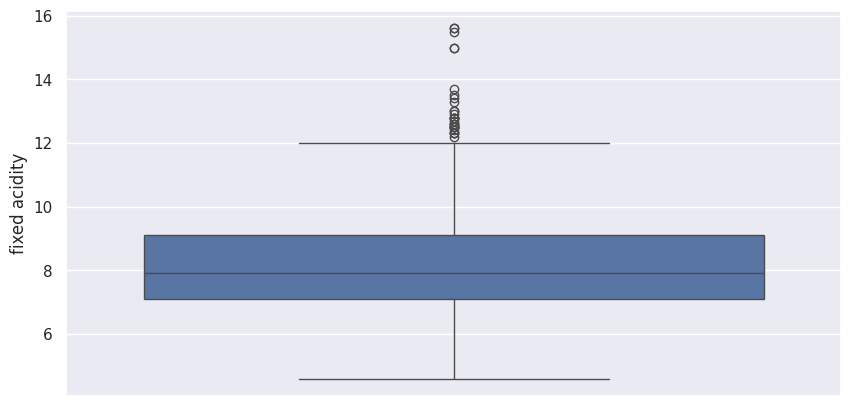

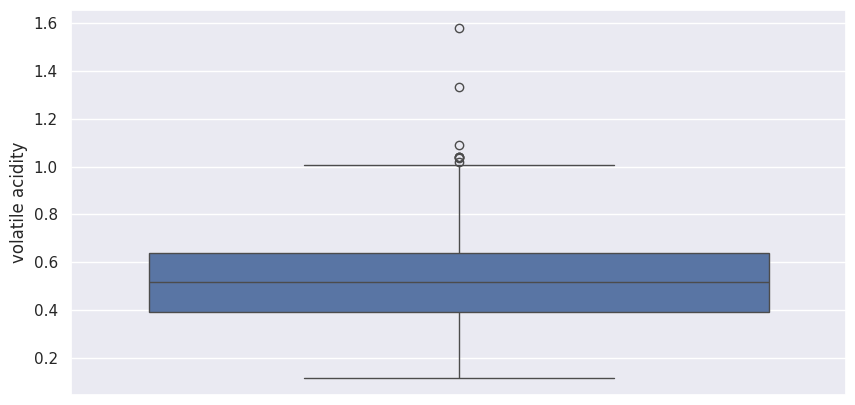

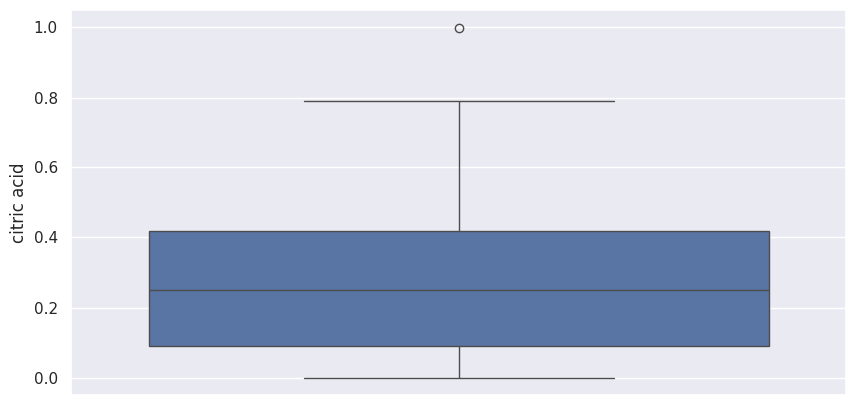

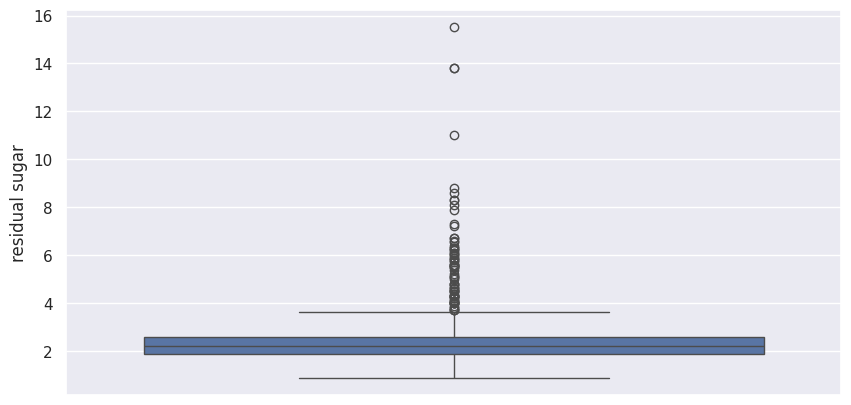

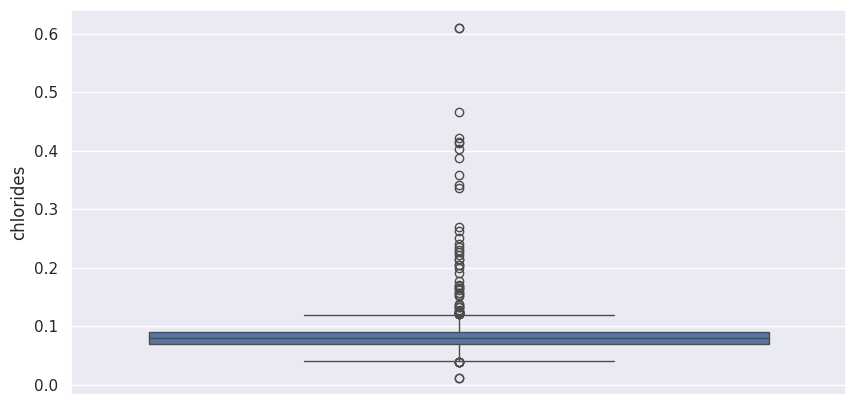

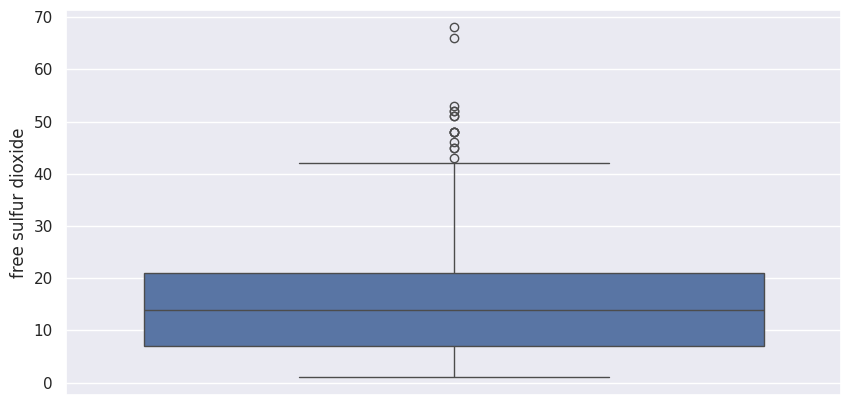

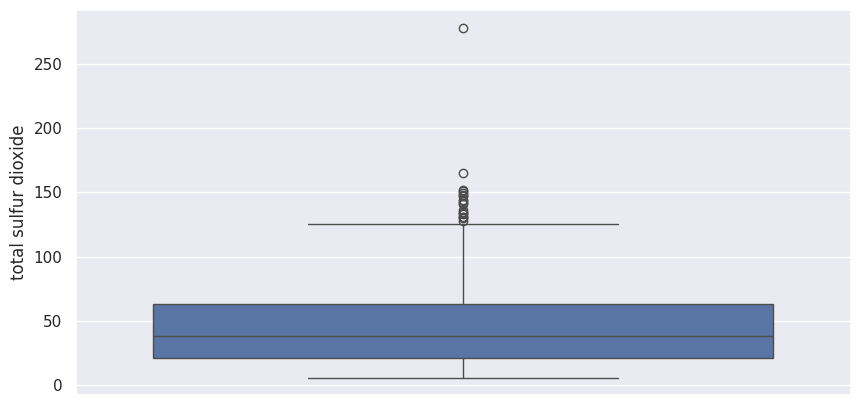

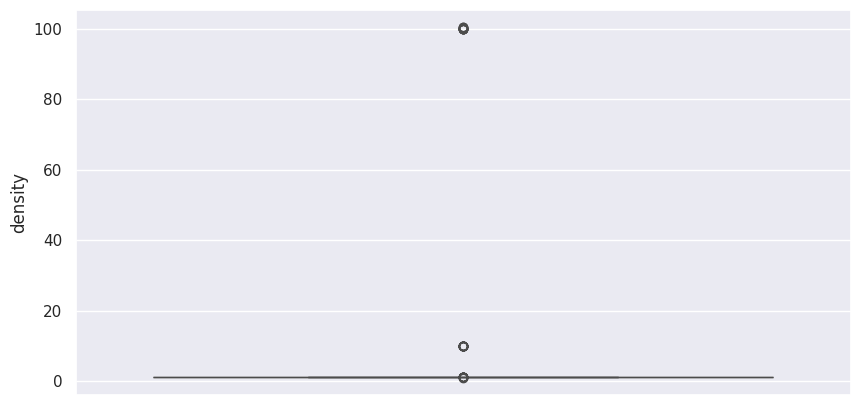

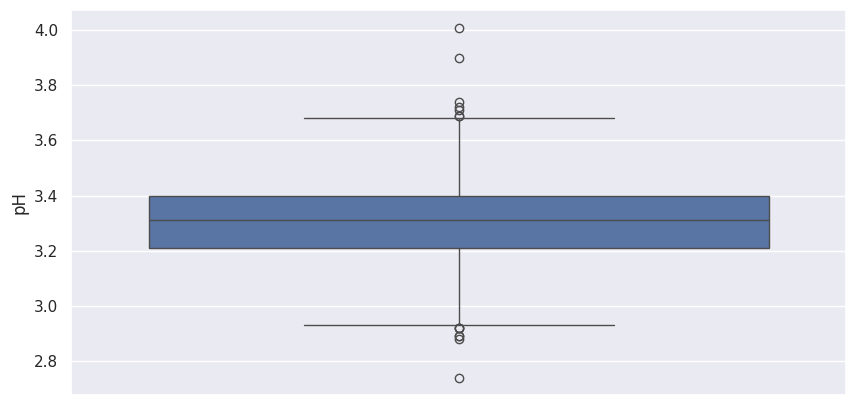

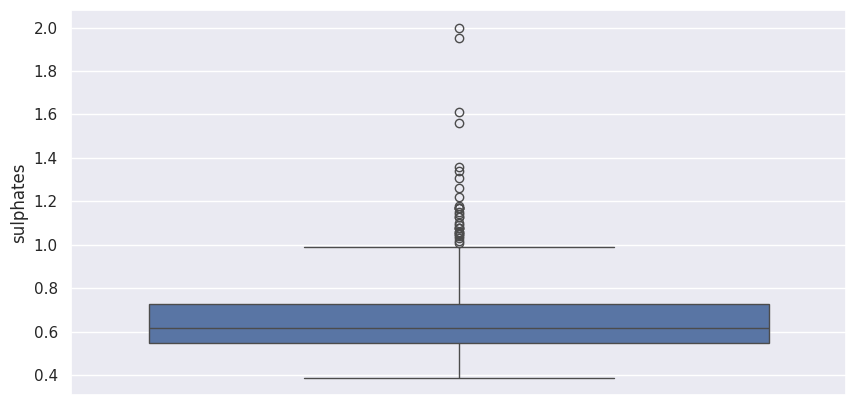

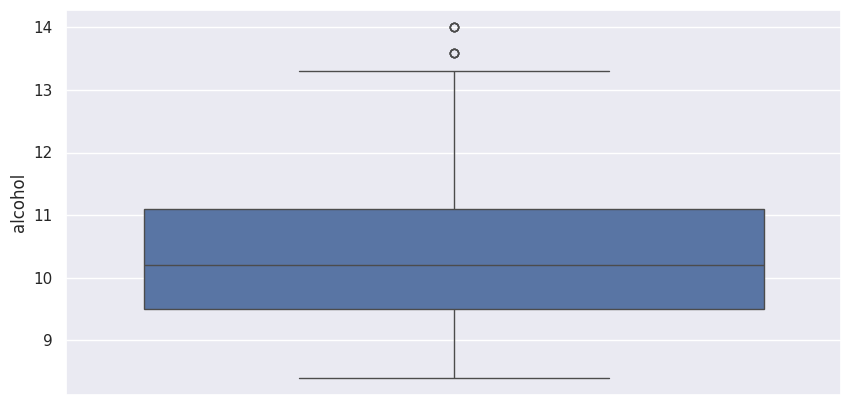

In [2295]:
# Convert 'alcohol' to numeric, coercing errors to NaN
training['alcohol'] = pd.to_numeric(training['alcohol'], errors='coerce')

# Fill NaN values in 'alcohol' with the median
training['alcohol'] = training['alcohol'].fillna(training['alcohol'].median())

plt.subplots(figsize = (10, 5))
sns.boxplot(training['fixed acidity'])
plt.annotate('Outlier', (training['fixed acidity'].max(),0.1), xytext = (training['fixed acidity'].max(),0.3),
 arrowprops = dict(facecolor = 'blue'), fontsize = 13 )
IQR = training['fixed acidity'].describe()['75%'] - training['fixed acidity'].describe()['25%']

plt.subplots(figsize = (10, 5))
sns.boxplot(training['volatile acidity'])
plt.annotate('Outlier', (training['volatile acidity'].max(),0.1), xytext = (training['volatile acidity'].max(),0.3),
 arrowprops = dict(facecolor = 'blue'), fontsize = 13 )
IQR = training['volatile acidity'].describe()['75%'] - training['volatile acidity'].describe()['25%']

plt.subplots(figsize = (10, 5))
sns.boxplot(training['citric acid'])
plt.annotate('Outlier', (training['citric acid'].max(),0.1), xytext = (training['citric acid'].max(),0.3),
 arrowprops = dict(facecolor = 'blue'), fontsize = 13 )
IQR = training['citric acid'].describe()['75%'] - training['citric acid'].describe()['25%']

plt.subplots(figsize = (10, 5))
sns.boxplot(training['residual sugar'])
plt.annotate('Outlier', (training['residual sugar'].max(),0.1), xytext = (training['residual sugar'].max(),0.3),
 arrowprops = dict(facecolor = 'blue'), fontsize = 13 )
IQR = training['residual sugar'].describe()['75%'] - training['residual sugar'].describe()['25%']

plt.subplots(figsize = (10, 5))
sns.boxplot(training['chlorides'])
plt.annotate('Outlier', (training['chlorides'].max(),0.1), xytext = (training['chlorides'].max(),0.3),
 arrowprops = dict(facecolor = 'blue'), fontsize = 13 )
IQR = training['chlorides'].describe()['75%'] - training['chlorides'].describe()['25%']

plt.subplots(figsize = (10, 5))
sns.boxplot(training['free sulfur dioxide'])
plt.annotate('Outlier', (training['free sulfur dioxide'].max(),0.1), xytext = (training['free sulfur dioxide'].max(),0.3),
 arrowprops = dict(facecolor = 'blue'), fontsize = 13 )
IQR = training['free sulfur dioxide'].describe()['75%'] - training['free sulfur dioxide'].describe()['25%']

plt.subplots(figsize = (10, 5))
sns.boxplot(training['total sulfur dioxide'])
plt.annotate('Outlier', (training['total sulfur dioxide'].max(),0.1), xytext = (training['total sulfur dioxide'].max(),0.3),
 arrowprops = dict(facecolor = 'blue'), fontsize = 13 )
IQR = training['total sulfur dioxide'].describe()['75%'] - training['total sulfur dioxide'].describe()['25%']

plt.subplots(figsize = (10, 5))
sns.boxplot(training['density'])
plt.annotate('Outlier', (training['density'].max(),0.1), xytext = (training['density'].max(),0.3),
 arrowprops = dict(facecolor = 'blue'), fontsize = 13 )
IQR = training['density'].describe()['75%'] - training['density'].describe()['25%']

plt.subplots(figsize = (10, 5))
sns.boxplot(training['pH'])
plt.annotate('Outlier', (training['pH'].max(),0.1), xytext = (training['pH'].max(),0.3),
 arrowprops = dict(facecolor = 'blue'), fontsize = 13 )
IQR = training['pH'].describe()['75%'] - training['pH'].describe()['25%']

plt.subplots(figsize = (10, 5))
sns.boxplot(training['sulphates'])
plt.annotate('Outlier', (training['sulphates'].max(),0.1), xytext = (training['sulphates'].max(),0.3),
 arrowprops = dict(facecolor = 'blue'), fontsize = 13 )
IQR = training['sulphates'].describe()['75%'] - training['sulphates'].describe()['25%']

plt.subplots(figsize = (10, 5))
sns.boxplot(training['alcohol'])
plt.annotate('Outlier', (training['alcohol'].max(),0.1), xytext = (training['alcohol'].max(),0.3),
 arrowprops = dict(facecolor = 'blue'), fontsize = 13 )
IQR = training['alcohol'].describe()['75%'] - training['alcohol'].describe()['25%']

Dari hasil boxplot di atas, terlihat bahwa semua variabel memiliki outlier. Untuk menangani outlier tersebut, langkah pertama yang akan diambil adalah dengan menghitung jumlah data outlier pada setiap kolom. Jika jumlah data outlier tergolong sedikit, maka data outlier tersebut dapat dihapus dari dataset. Namun, jika jumlah data outlier terlalu banyak, maka menghapus data tersebut dapat mengurangi jumlah sampel yang signifikan untuk pelatihan dan pengujian model.

### Penanganan outlier

In [2296]:
from scipy import stats
z = np.abs(stats.zscore(training._get_numeric_data()))
#mendapatkan data yang tidak outlier pada semua variabel
training1 = training[(z<3).all(axis=1)]
training1

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918
5,9.6,0.600,0.50,2.3,0.079,28.0,71.0,0.99970,3.50,0.57,9.7,5,616
...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,6.7,1.040,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0,4,1467
853,8.0,0.390,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0,5,1533
854,7.4,0.350,0.33,2.4,0.068,9.0,26.0,0.99470,3.36,0.60,11.9,6,1580
855,7.9,0.570,0.31,2.0,0.079,10.0,79.0,0.99677,3.29,0.69,9.5,6,1216


Dapat dilihat bahwa setelah dilakukan mengatasi outlier, data kualitas wine menjadi sebanyak 776 data. Lalu selanjutnya dilakukan pengecekan kembali menggunakan boxplot pada masing-masing variabel untuk mengetahui masihkah ada outlier dalam tiap variabel.

### Cek ulang outlier

<Axes: ylabel='alcohol'>

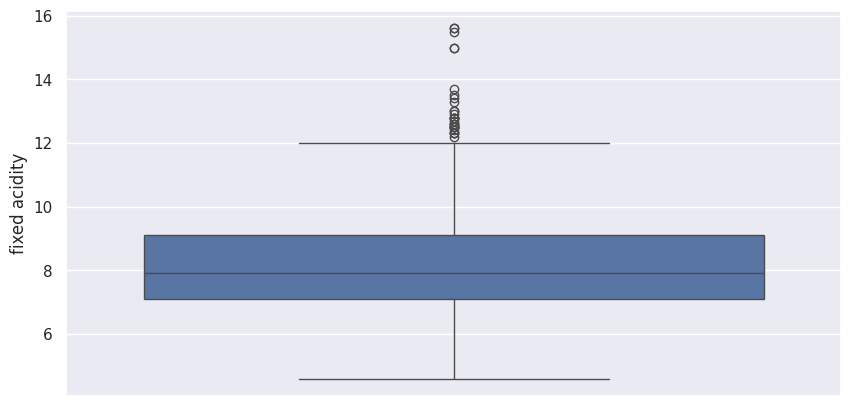

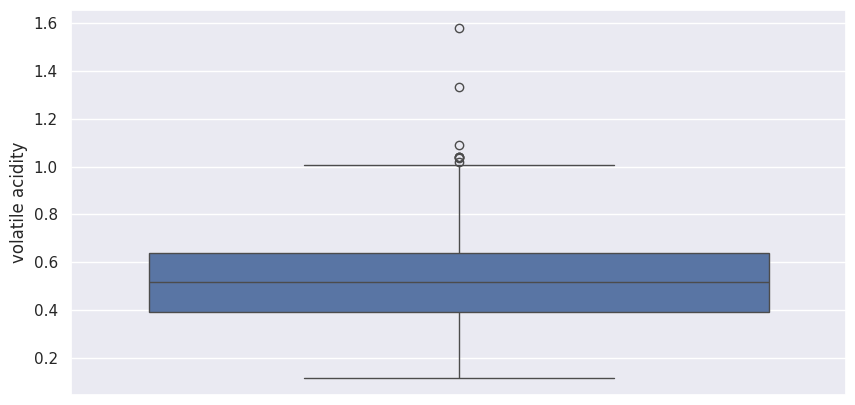

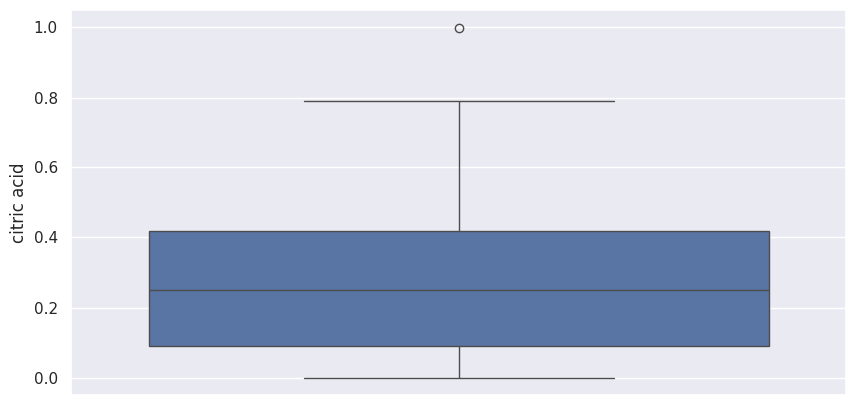

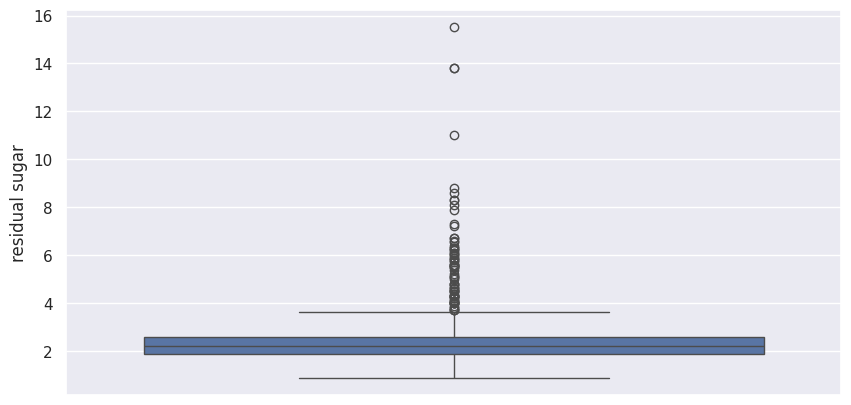

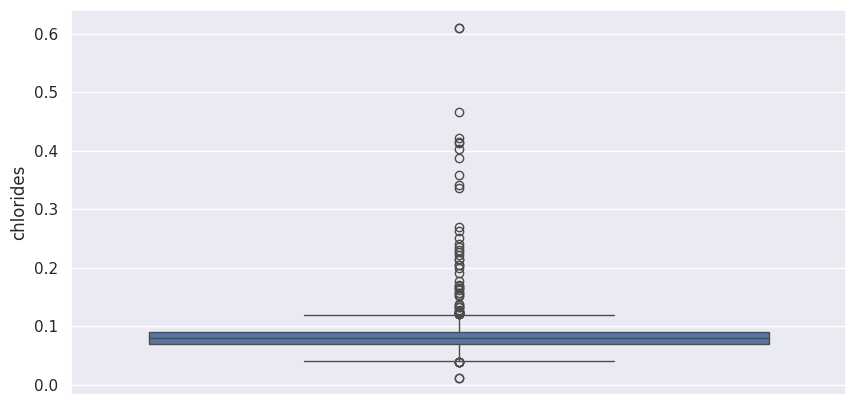

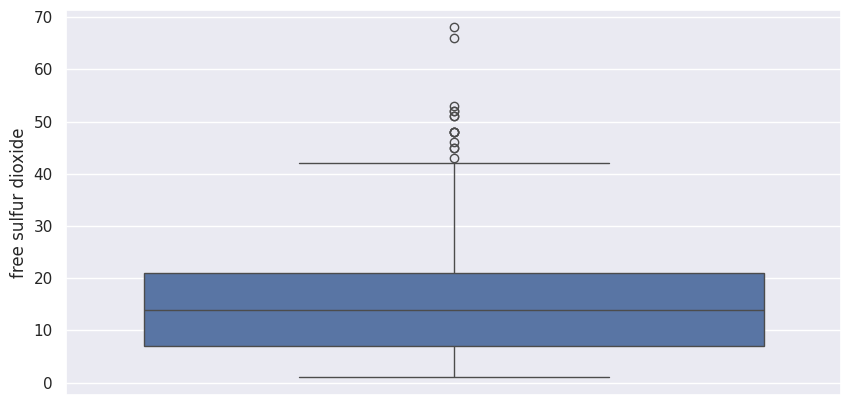

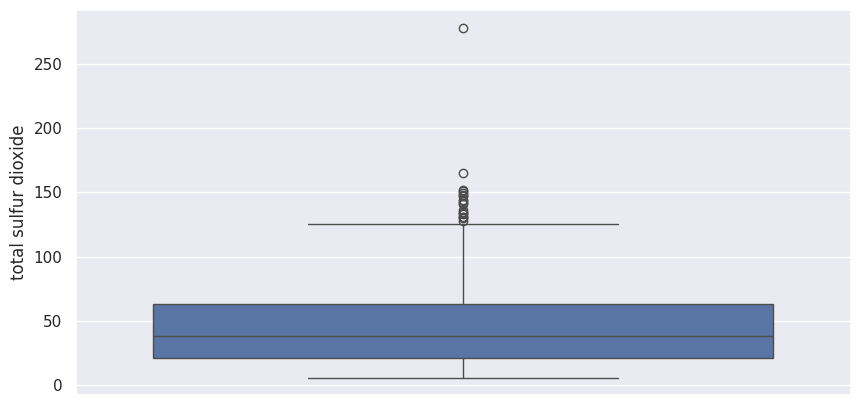

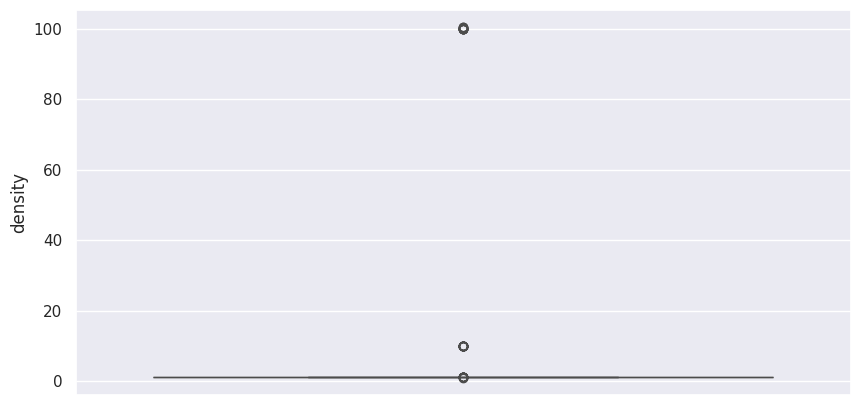

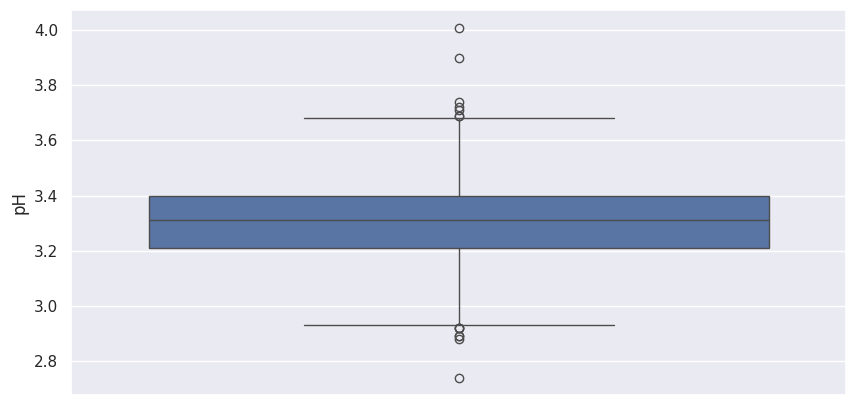

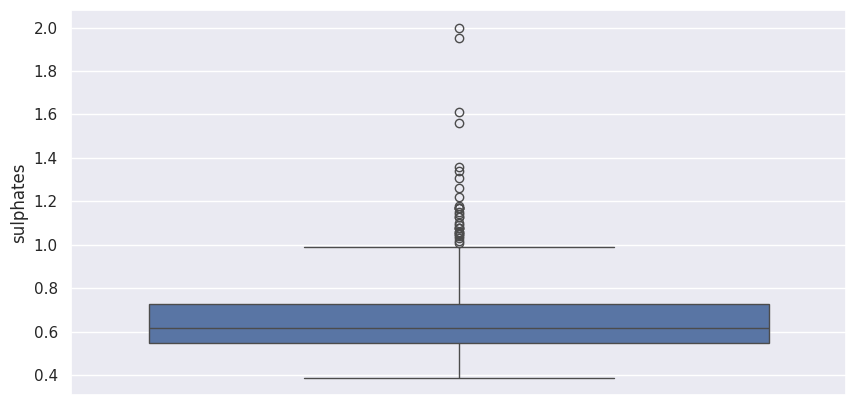

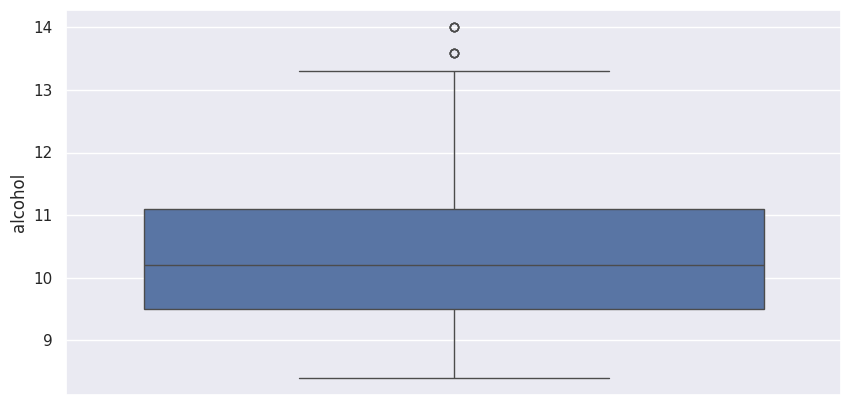

In [2297]:
plt.subplots(figsize = (10, 5))
sns.boxplot(training['fixed acidity'])

plt.subplots(figsize = (10, 5))
sns.boxplot(training['volatile acidity'])

plt.subplots(figsize = (10, 5))
sns.boxplot(training['citric acid'])

plt.subplots(figsize = (10, 5))
sns.boxplot(training['residual sugar'])

plt.subplots(figsize = (10, 5))
sns.boxplot(training['chlorides'])

plt.subplots(figsize = (10, 5))
sns.boxplot(training['free sulfur dioxide'])

plt.subplots(figsize = (10, 5))
sns.boxplot(training['total sulfur dioxide'])

plt.subplots(figsize = (10, 5))
sns.boxplot(training['density'])

plt.subplots(figsize = (10, 5))
sns.boxplot(training['pH'])

plt.subplots(figsize = (10, 5))
sns.boxplot(training['sulphates'])

plt.subplots(figsize = (10, 5))
sns.boxplot(training['alcohol'])

Terlihat masih banyak outlier, maka pada kasus ini, outlier pada kasus kualitas wine tetap digunakan, sehingga dpaat dilanjutkan untuk analisis lanjut.

### Cek data imbalanced

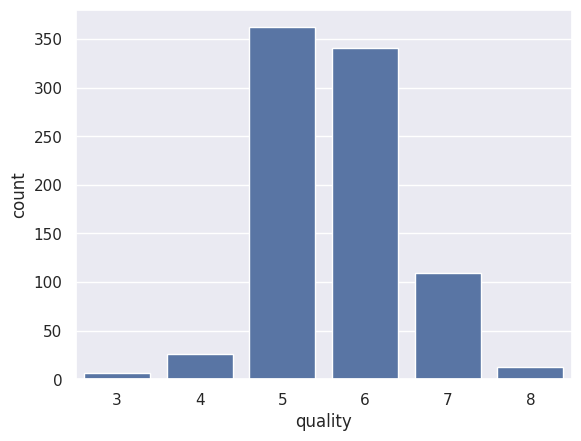

quality
5    0.422404
6    0.397900
7    0.127188
4    0.030338
8    0.015169
3    0.007001
Name: count, dtype: float64


In [2298]:
# Mencari apakah dataset (kolom quality) imbalanced atau tidak
sns.countplot(x='quality',data=training)
plt.show()
persentase = training['quality'].value_counts()/training.shape[0]
print(persentase)

Berdasarkan hasil perhitungan proporsi pada variabel quality, dapat diketahui bahwa terdapat ketidakseimbangan (imbalanced data) antar kelas. Nilai quality = 5 memiliki persentase tertinggi yaitu sebesar 42.24%, diikuti oleh quality = 6 sebesar 39.79%. Sementara itu, kelas dengan nilai 7 hanya memiliki proporsi 12.72%, dan nilai 4, 8, serta 3 memiliki persentase yang jauh lebih kecil masing-masing sebesar 3.03%, 1.52%, dan 0.70%.

Dengan demikian, dapat disimpulkan bahwa kelas mayoritas dalam dataset ini adalah quality 5 dan 6, yang secara bersama-sama mencakup lebih dari 80% dari total data, sedangkan kelas lainnya merupakan kelas minoritas dengan proporsi yang jauh lebih kecil. Kondisi ini menunjukkan adanya ketidakseimbangan distribusi kelas pada variabel quality. Ketidakseimbangan ini berpotensi memengaruhi kinerja model klasifikasi, karena model cenderung lebih akurat dalam memprediksi kelas mayoritas dan kurang mampu mengenali kelas minoritas.

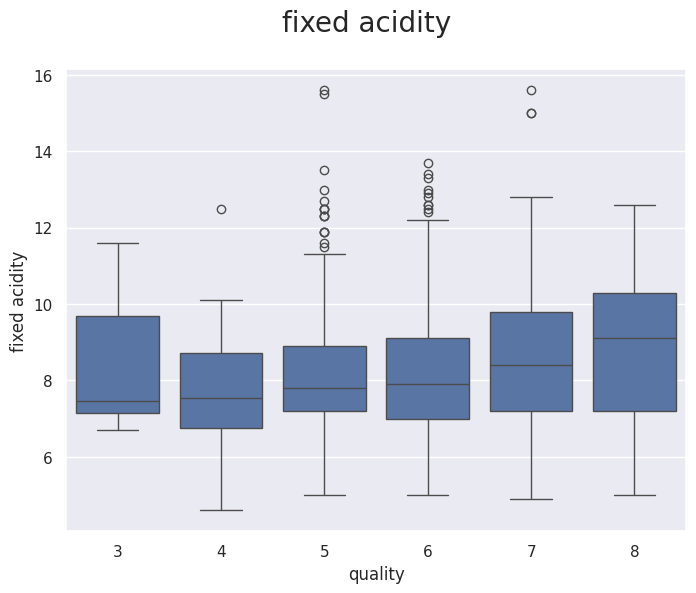

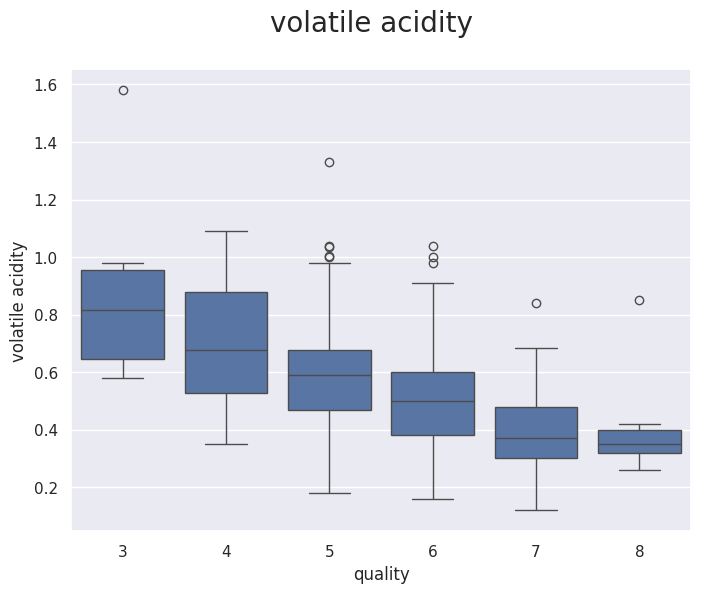

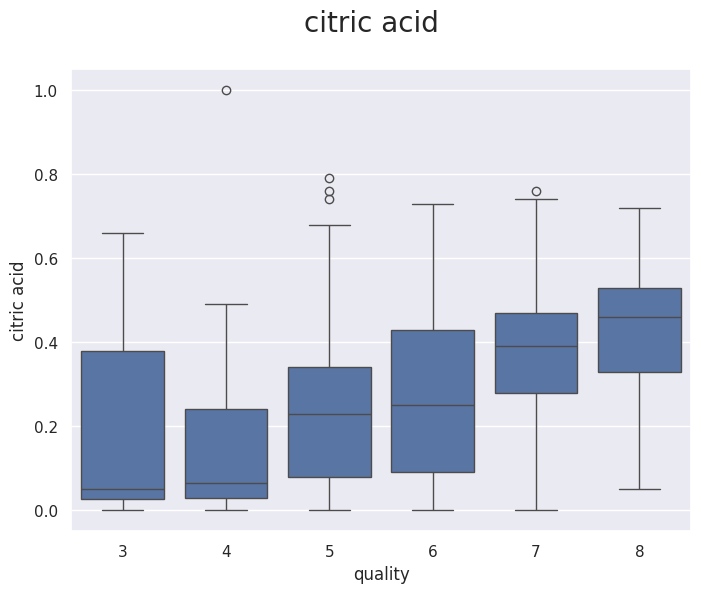

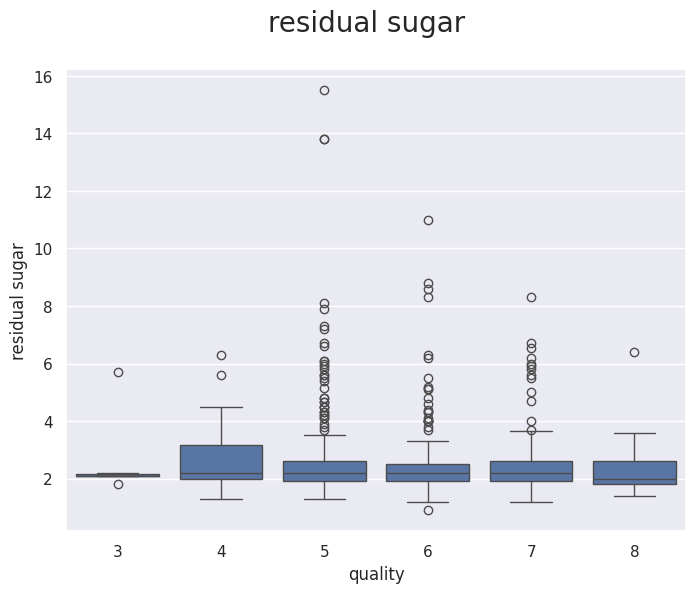

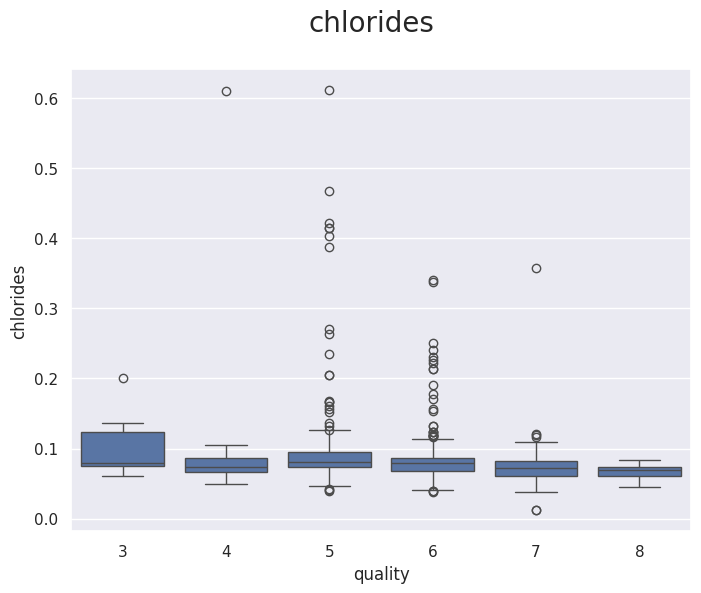

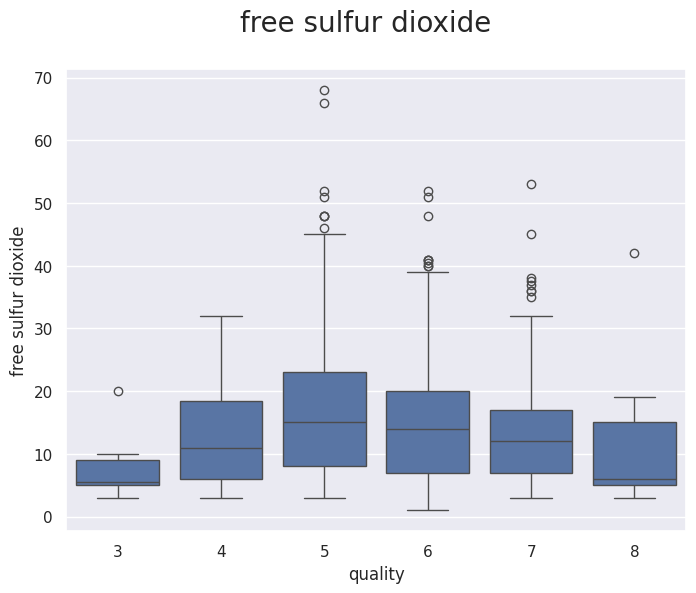

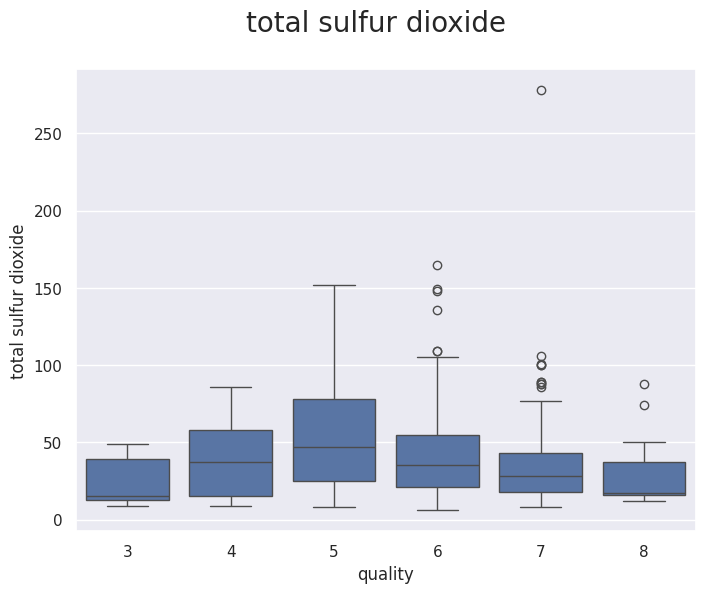

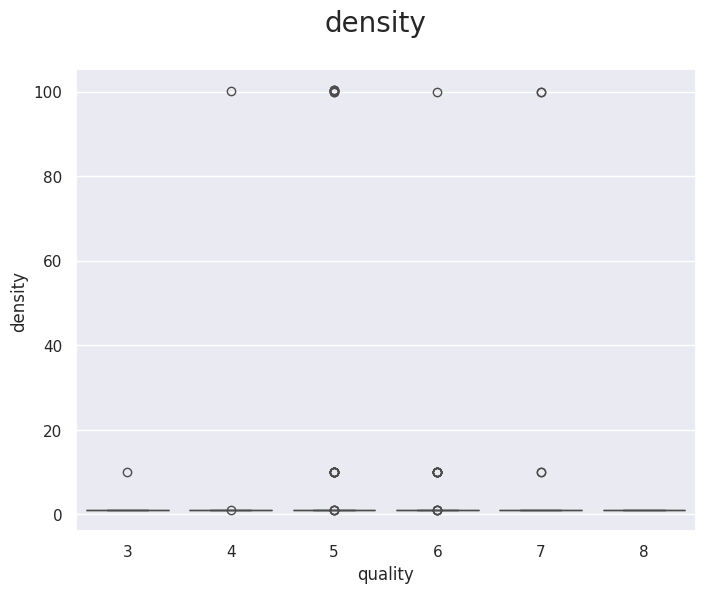

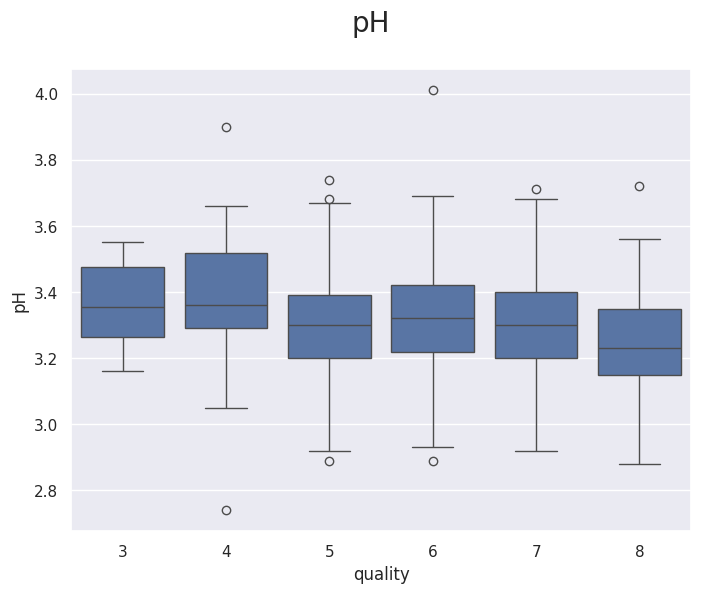

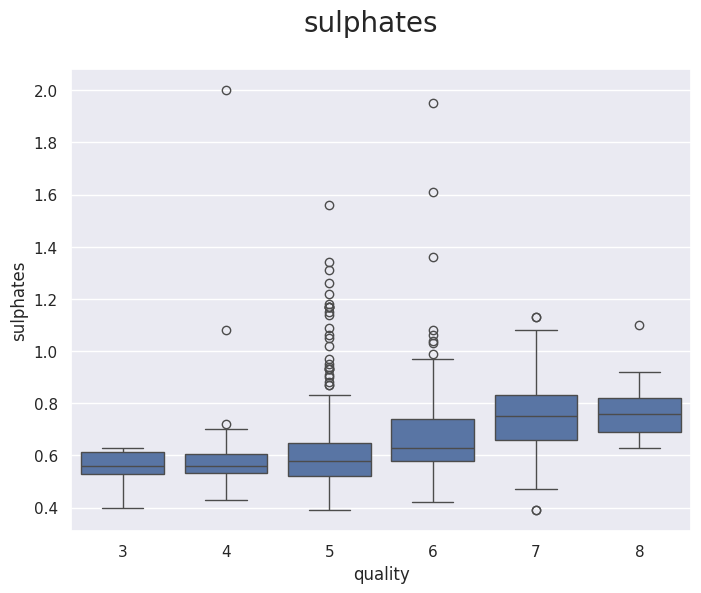

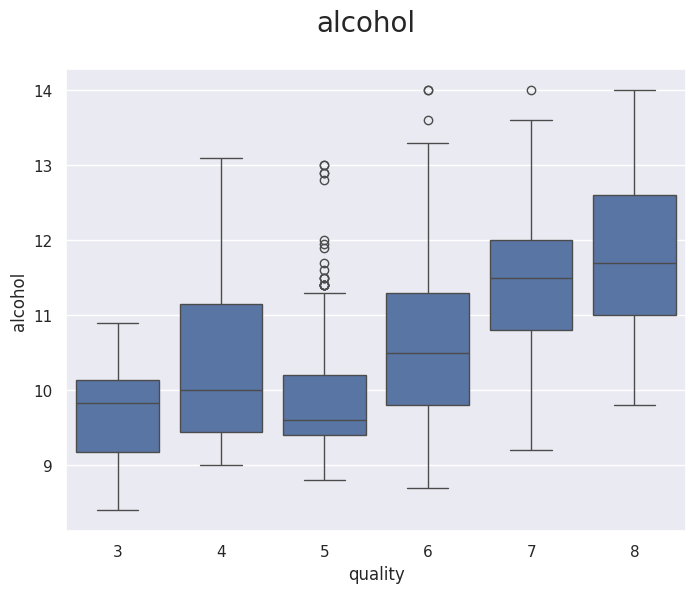

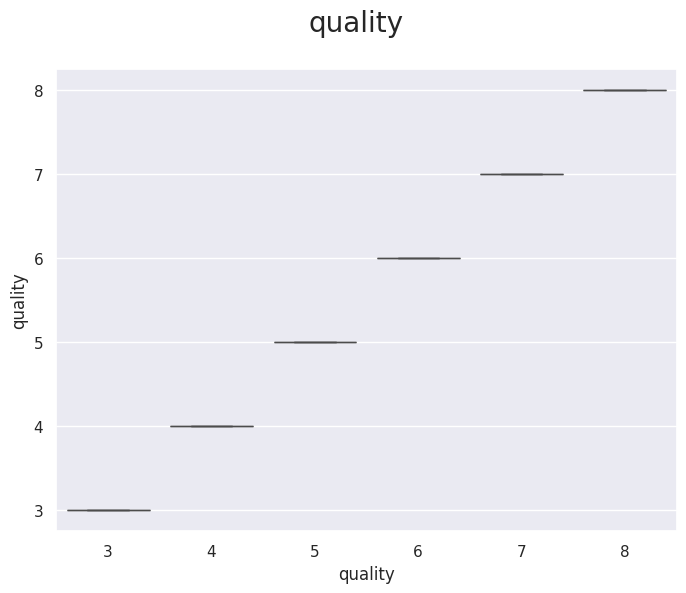

In [2299]:
# Mencari fitur apa saja yang kemungkinan menjadi prediktor yang baik
import matplotlib.pyplot as plt
import seaborn as sns

# Iterasi untuk membuat box plot untuk setiap fitur numerik terhadap kolom 'quality'
for feature in training.describe(exclude='object').columns[:-1]:
    plt.figure(figsize=(8, 6))
    plt.suptitle(feature, fontsize=20)
    sns.boxplot(data=training, y=feature, x='quality')
    plt.show()

Berdasarkan boxplot tersebut, dapat dilihat bahwa ada beberapa fitur yang mungkin dapat menjadi prediktor yang baik yaitu:

1. Volatile acidity
2.   Item daftar



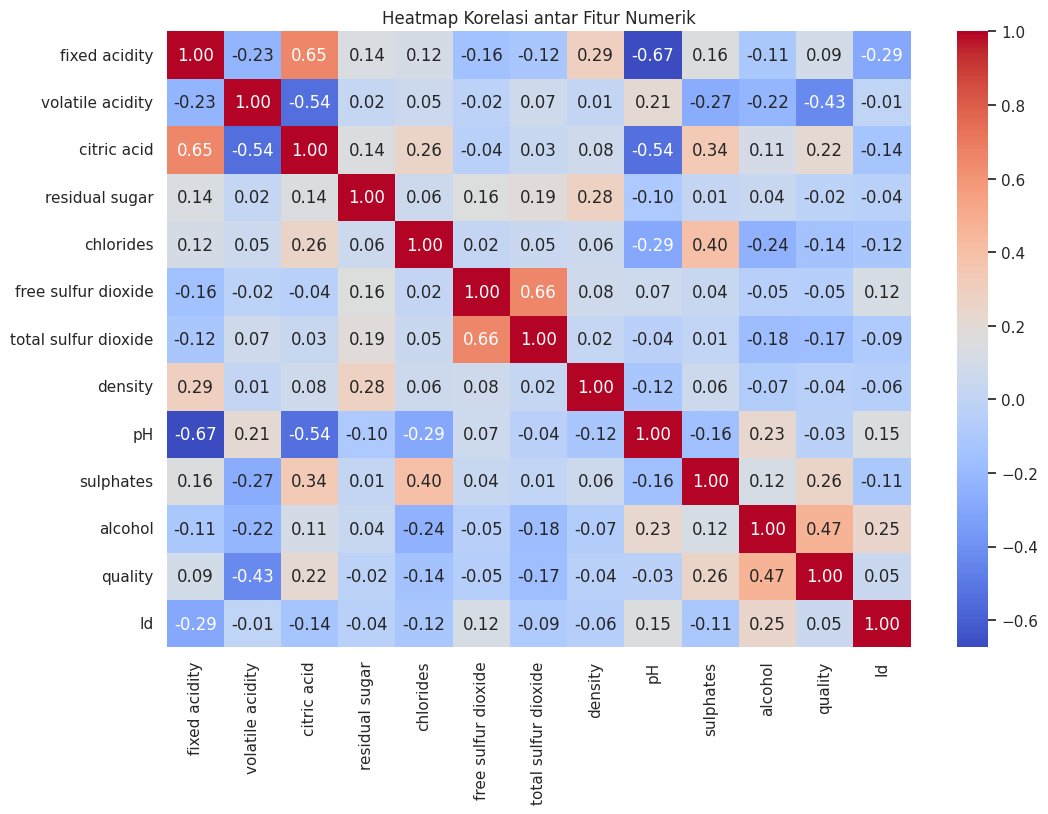

In [2300]:
# Hitung matriks korelasi
correlation_matrix = training.select_dtypes(include=np.number).corr()

# Plot heatmap dari matriks korelasi
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi antar Fitur Numerik")
plt.show()

Dari matriks korelasi di atas, kita dapat mengamati bahwa korelasi tertinggi positif terdapat antara variabel ‘density’ dan ‘fixed acidity’ dengan nilai sekitar 0.29, yang menunjukkan bahwa semakin tinggi kadar keasaman tetap, maka kepadatan (density) cenderung meningkat.

Sementara itu, korelasi negatif yang paling kuat terlihat antara ‘pH’ dan ‘fixed acidity’ dengan nilai -0.67. Hal ini berarti bahwa semakin tinggi tingkat keasaman (fixed acidity), maka nilai pH akan semakin rendah — sesuai dengan sifat kimia asam yang menurunkan pH larutan.

Selain itu, variabel ‘alcohol’ juga menunjukkan korelasi positif yang cukup signifikan dengan ‘quality’ sebesar 0.44, menandakan bahwa kadar alkohol yang lebih tinggi cenderung meningkatkan kualitas anggur menurut penilaian data ini. Oleh karena itu, ‘alcohol’ dapat dianggap sebagai salah satu prediktor yang baik untuk menentukan kualitas wine.

## Summary Data Understanding dan Data Cleaning

### Informasi Dasar Dataset:
1. Jumlah kolom: 13
2. Jumlah baris: 857
3. DataType dari setiap kolom: float64(10), int64(2), object(1)

### Data kosong:
Semua data terisi, tidak ada data kosong

###Deskripsi Dataset:
- Dataset terdiri dari 857 observasi
- Nilai fixed acidity memiliki rata-rata 8,26
- Volatile acidity memiliki rata-rata 0,52
- Nilai citric acid memiliki rata-rata 0,27
- Nilai residual sugar memiliki rata-rata sebesar 2,51
- Kandungan chlorides memiliki rata-rata 0,086
- Rata-rata free sulfur dioxide sebesar 15,78
- Rata-rata total sulfur dioxide yaitu 45,98
- Nilai density rata-rata sebesar 0,996
- Nilai pH memiliki rata-rata sebesar 3,31
- Nilai sulphates memiliki rata-rata 0,66
- Nilai quality memiliki rata-rata 5,65

### Outlier:
Semua variabel memiliki outlier.

### Predictor Feature:
Fitur yang mungkin menjadi prediktor yang baik adalah:
1. Density

## Data Eksplorasi

### Presentase Kualitas Wine

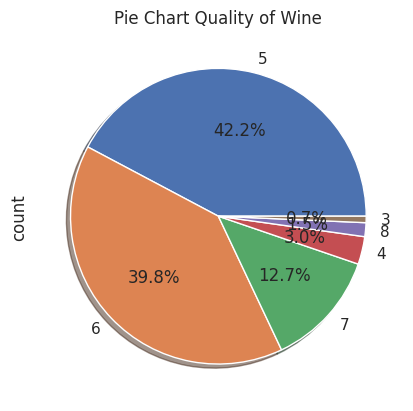

In [2301]:
tipe = training['quality'].value_counts()
tipe.plot.pie(autopct='%.1f%%', shadow=True)
plt.title('Pie Chart Quality of Wine')
plt.show()

Dari pie chart di atas, terlihat distribusi quality (kualitas) wine berdasarkan nilainya. Kualitas dengan nilai 5 dan 6 mendominasi dataset dengan proporsi masing-masing 42.2% dan 39.8%. Hal ini menunjukkan bahwa sebagian besar wine dalam dataset termasuk dalam kategori kualitas sedang.

Sementara itu, wine dengan kualitas 7 hanya mencakup 12.7%, dan kualitas yang lebih rendah seperti 3 dan 4 memiliki proporsi yang sangat kecil, masing-masing 0.7% dan 3.0%. Kualitas tertinggi, yaitu 8, juga hanya mencakup sebagian kecil dari keseluruhan data.

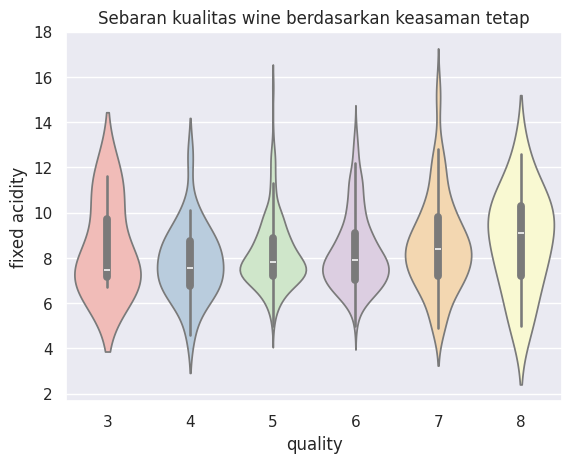

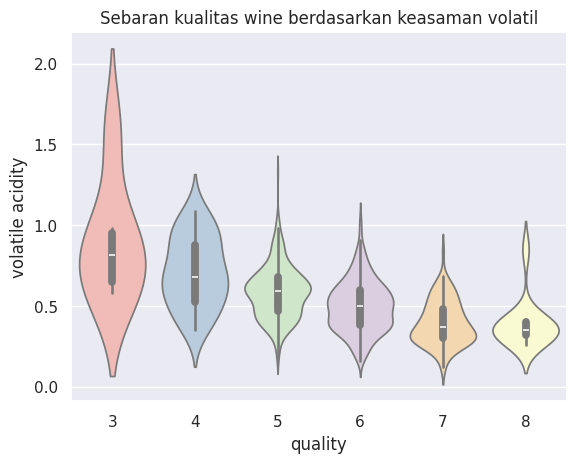

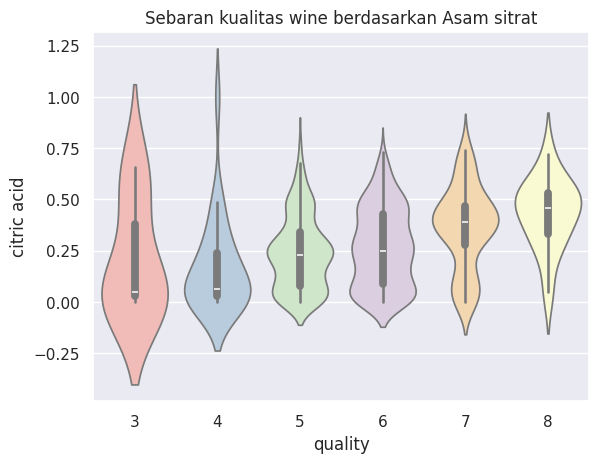

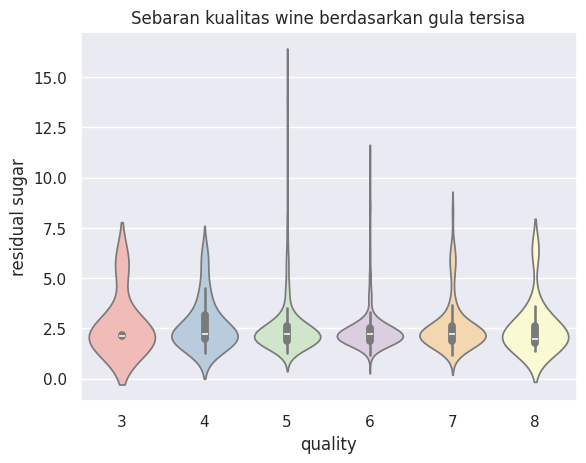

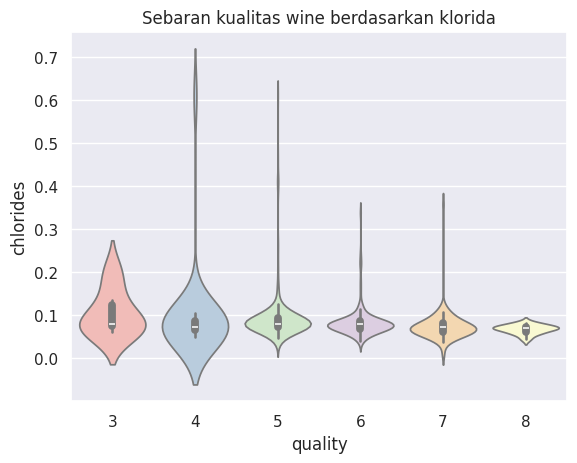

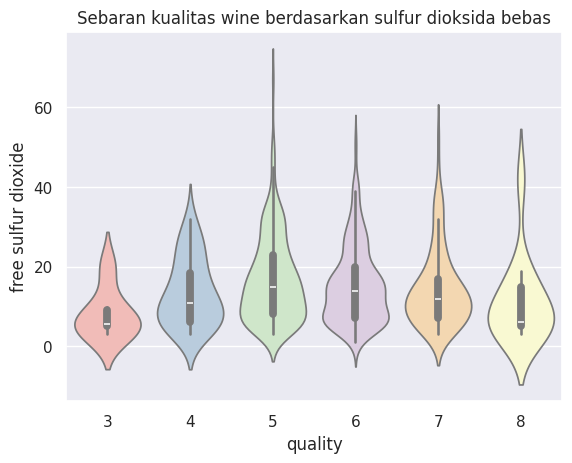

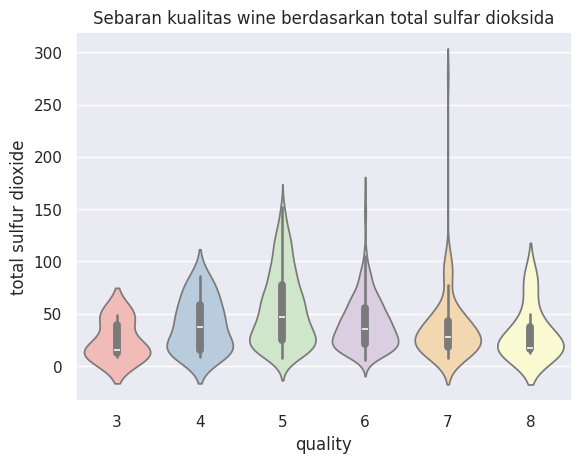

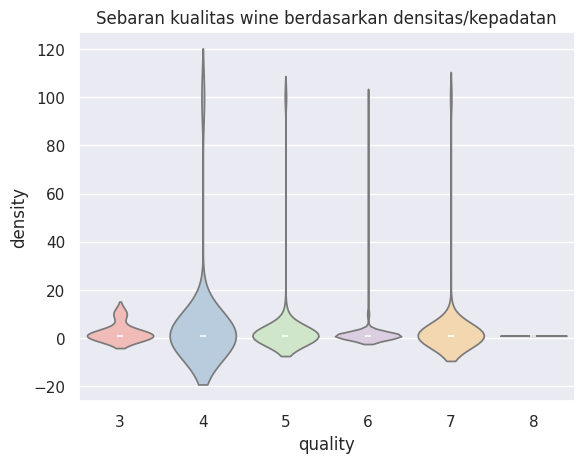

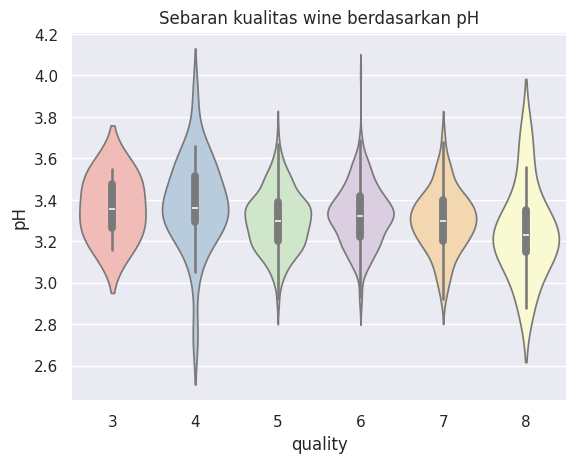

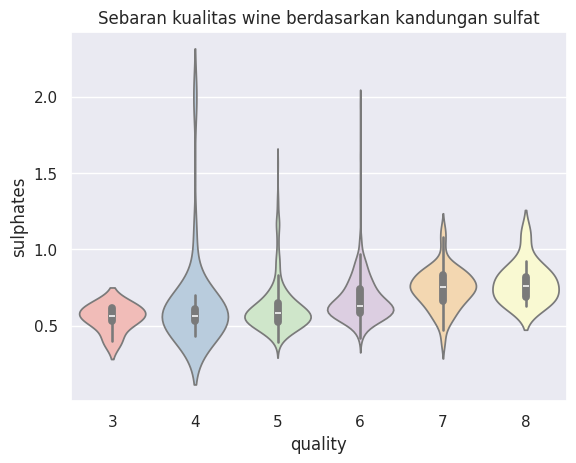

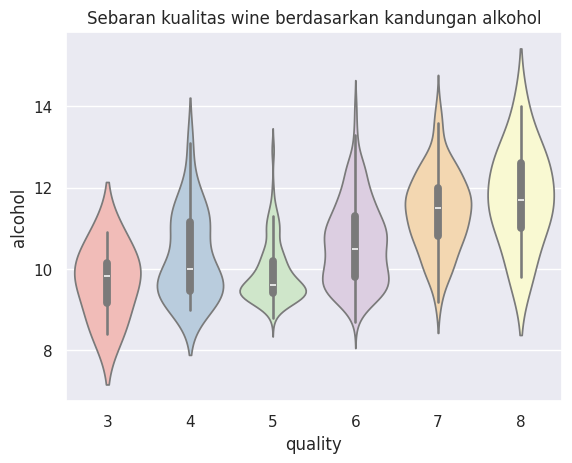

In [2302]:
#Sebaran kualitas wine berdasarkan Keasaman tetap
sns.set(style="darkgrid")
sns.violinplot(x='quality',y='fixed acidity',data=training,palette="Pastel1")
plt.title('Sebaran kualitas wine berdasarkan keasaman tetap')
plt.show()

#Sebaran kualitas wine berdasarkan Keasaman volatil
sns.set(style="darkgrid")
sns.violinplot(x='quality',y='volatile acidity',data=training,palette="Pastel1")
plt.title('Sebaran kualitas wine berdasarkan keasaman volatil')
plt.show()

#Sebaran kualitas wine berdasarkan Asam sitrat
sns.set(style="darkgrid")
sns.violinplot(x='quality',y='citric acid',data=training,palette="Pastel1")
plt.title('Sebaran kualitas wine berdasarkan Asam sitrat')
plt.show()

#Sebaran kualitas wine berdasarkan Gula tersisa
sns.set(style="darkgrid")
sns.violinplot(x='quality',y='residual sugar',data=training,palette="Pastel1")
plt.title('Sebaran kualitas wine berdasarkan gula tersisa')
plt.show()

#Sebaran kualitas wine berdasarkan Kandungan Klorida
sns.set(style="darkgrid")
sns.violinplot(x='quality',y='chlorides',data=training,palette="Pastel1")
plt.title('Sebaran kualitas wine berdasarkan klorida')
plt.show()

#Sebaran kualitas wine berdasarkan Sulfur Dioksida bebas
sns.set(style="darkgrid")
sns.violinplot(x='quality',y='free sulfur dioxide',data=training,palette="Pastel1")
plt.title('Sebaran kualitas wine berdasarkan sulfur dioksida bebas')
plt.show()

#Sebaran kualitas wine berdasarkan Total sulfar dioksida
sns.set(style="darkgrid")
sns.violinplot(x='quality',y='total sulfur dioxide',data=training,palette="Pastel1")
plt.title('Sebaran kualitas wine berdasarkan total sulfar dioksida')
plt.show()

#Sebaran kualitas wine berdasarkan Densitas/kepadatan
sns.set(style="darkgrid")
sns.violinplot(x='quality',y='density',data=training,palette="Pastel1")
plt.title('Sebaran kualitas wine berdasarkan densitas/kepadatan')
plt.show()

#Sebaran kualitas wine berdasarkan pH
sns.set(style="darkgrid")
sns.violinplot(x='quality',y='pH',data=training,palette="Pastel1")
plt.title('Sebaran kualitas wine berdasarkan pH')
plt.show()

#Sebaran kualitas wine berdasarkan kandungan sulfat
sns.set(style="darkgrid")
sns.violinplot(x='quality',y='sulphates',data=training,palette="Pastel1")
plt.title('Sebaran kualitas wine berdasarkan kandungan sulfat')
plt.show()

#Sebaran kualitas wine berdasarkan kadar alkohol
sns.set(style="darkgrid")
sns.violinplot(x='quality',y='alcohol',data=training,palette="Pastel1")
plt.title('Sebaran kualitas wine berdasarkan kandungan alkohol')
plt.show()

- **Sebaran kualitas wine berdasarkan keasaman tetap** violin di atas menunjukkan sebaran kualitas wine (quality) berdasarkan fixed acidity (keasaman tetap). Terlihat bahwa nilai fixed acidity cenderung berkisar antara 6 hingga 10 untuk hampir semua tingkat kualitas. Namun, wine dengan kualitas lebih tinggi (7 dan 8) umumnya memiliki nilai fixed acidity yang sedikit lebih besar dibandingkan kualitas rendah. Hal ini menunjukkan bahwa tingkat keasaman tetap dapat berpengaruh terhadap kualitas wine, meskipun perbedaannya tidak terlalu mencolok.
- **Sebaran kualitas wine berdasarkan keasaman volatil**
Grafik menunjukkan bahwa semakin tinggi kualitas wine, nilai volatile acidity (keasaman volatil) cenderung lebih rendah. Wine dengan kualitas rendah (3–4) memiliki keasaman volatil lebih tinggi dan sebaran yang lebih lebar, sedangkan wine berkualitas tinggi (7–8) memiliki keasaman volatil lebih kecil dan konsisten.
- **Sebaran kualitas wine berdasarkan asam sitrat**
Grafik menunjukkan bahwa semakin tinggi kualitas wine, kadar asam sitrat (citric acid) cenderung lebih tinggi. Wine dengan kualitas rendah (3–4) memiliki kadar asam sitrat rendah, sedangkan wine berkualitas tinggi (7–8) memiliki kadar asam sitrat yang lebih besar dan distribusi yang lebih stabil.
- **Sebaran kualitas wine berdasarkan gula tersisa**
Grafik menunjukkan bahwa kadar gula tersisa (residual sugar) tidak memiliki pola yang jelas terhadap kualitas wine. Sebaran gula tersisa relatif mirip di semua tingkat kualitas, meskipun beberapa outlier muncul pada kualitas menengah (terutama di kualitas 5).
- **Sebaran kualitas wine berdasarkan klorida**
Grafik tersebut menunjukkan sebaran kadar klorida pada wine berdasarkan kualitasnya. Terlihat bahwa wine dengan kualitas lebih tinggi (7–8) cenderung memiliki kadar klorida yang lebih rendah dan lebih konsisten, sedangkan wine dengan kualitas rendah (3–4) memiliki sebaran klorida yang lebih besar, menandakan variasi kadar garam yang lebih tinggi.
- **Sebaran kualitas wine berdasarkan sulfur dioksida bebas**
Grafik tersebut menunjukkan sebaran kadar sulfur dioksida bebas pada wine berdasarkan kualitasnya. Terlihat bahwa kadar sulfur dioksida bebas cenderung bervariasi di semua tingkat kualitas, namun wine dengan kualitas sedang (5–6) memiliki rentang nilai yang paling lebar. Secara umum, tidak ada pola yang jelas antara kadar sulfur dioksida bebas dan kualitas wine.
- **Sebaran kualitas wine berdasarkan total sulfur dioksida**
Grafik tersebut memperlihatkan sebaran total sulfur dioksida pada wine berdasarkan kualitasnya. Terlihat bahwa kualitas sedang (4–6) memiliki rentang nilai total sulfur dioksida yang paling lebar, sedangkan wine dengan kualitas tinggi (7–8) cenderung memiliki kadar total sulfur dioksida yang lebih rendah dan lebih stabil. Ini mengindikasikan bahwa total sulfur dioksida yang terlalu tinggi mungkin berhubungan dengan kualitas wine yang lebih rendah.
- **Sebaran kualitas wine berdasarkan densitas**
Grafik tersebut memperlihatkan sebaran densitas pada wine berdasarkan kualitasnya.
**Sebaran kualitas wine berdasarkan pH**
Grafik tersebut memperlihatkan sebaran pH pada wine berdasarkan kualitasnya.
**Sebaran kualitas wine berdasarkan kandungan sulfat**
Grafik tersebut memperlihatkan sebaran kandungan sulfat pada wine berdasarkan kualitasnya.
**Sebaran kualitas wine berdasarkan kandungan alkohol**
Grafik tersebut memperlihatkan sebaran kandungan alkohol pada wine berdasarkan kualitasnya.

Modeling dan Evaluasi

In [2303]:
#Metrics
from sklearn.metrics import make_scorer, accuracy_score,precision_score
from sklearn.metrics import classification_report

#Metrics
from sklearn.metrics import make_scorer, accuracy_score,precision_score
from sklearn.metrics import classification_report

# Import libarary confusion matrix
from sklearn.metrics import confusion_matrix

from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score,average_precision_score,roc_auc_score
from sklearn.metrics import r2_score

Memanggil library dari tap package yang akan digunakan untuk tahap data spliting, modelling, evaluasi

Data spliting

In [2304]:
# Pisahkan fitur dan label
X = training.drop(columns=['quality', 'Id'])
y = training['quality']

# Train dan test split (pakai y_encoded untuk stratify)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames to use .info()
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)


#Menampilkan deskripsi data training dan testing
print("========= Info Data Training =========")
X_train_scaled_df.info()
print("\nJumlah baris data training:", X_train_scaled_df.shape[0])
print("Jumlah fitur data training:", X_train_scaled_df.shape[1])

print("\n========= Info Data Testing =========")
X_test_scaled_df.info()
print("\nJumlah baris data testing:", X_test_scaled_df.shape[0])
print("Jumlah fitur data testing:", X_test_scaled_df.shape[1])

========= Info Data Training =========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         685 non-null    float64
 1   volatile acidity      685 non-null    float64
 2   citric acid           685 non-null    float64
 3   residual sugar        685 non-null    float64
 4   chlorides             685 non-null    float64
 5   free sulfur dioxide   685 non-null    float64
 6   total sulfur dioxide  685 non-null    float64
 7   density               685 non-null    float64
 8   pH                    685 non-null    float64
 9   sulphates             685 non-null    float64
 10  alcohol               685 non-null    float64
dtypes: float64(11)
memory usage: 59.0 KB

Jumlah baris data training: 685
Jumlah fitur data training: 11

========= Info Data Testing =========
<class 'pandas.core.frame.DataFrame'>
RangeIndex

Pada proses data splitting, dataset dibagi menjadi 2 bagian, yaitu data untuk training dan data untuk testing. Pembagian data tersebut diatur sebesar 80% untuk data training dan 20% untuk data testing. Berdasarkan hasil informasi tersebut, data training berjumlah 685 baris dan data testing 172 baris, masing-masing memiliki 11 kolom fitur dengan tipe data numerik (float64). Seluruh kolom seperti fixed acidity, volatile acidity, citric acid, hingga alcohol merupakan variabel kimia yang memengaruhi kualitas produk. Karena struktur dan tipe data keduanya sama, data testing sudah siap digunakan untuk prediksi menggunakan model Random Forest tanpa perlu preprocessing tambahan.

### Modelling
Model yang digunakan adalah Random Forest

In [2305]:
# ========================
# MODEL  RANDOM FOREST (BASELINE)
# ========================

# Import Library Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

In [2306]:
# -----------------------
# Train & Test (Random Forest)
# -----------------------

random_forest = RandomForestClassifier(
    n_estimators=400,
    random_state=0,
)

# Latih model
random_forest.fit(X_train, y_train)

# Prediksi data test
Y_predrf = random_forest.predict(X_test)

In [2307]:
# -----------------------
# Evaluasi Model — Random Forest
# -----------------------
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, average_precision_score, roc_auc_score
)

# Confusion Matrix & Akurasi
cm_rf = confusion_matrix(y_test, Y_predrf)
accuracy_rf = accuracy_score(y_test, Y_predrf)

# Gunakan 'average=weighted' karena dataset multiclass & imbalanced
precision_rf = precision_score(y_test, Y_predrf, average='weighted', zero_division=0)
recall_rf    = recall_score(y_test, Y_predrf, average='weighted', zero_division=0)
f1_rf        = f1_score(y_test, Y_predrf, average='weighted', zero_division=0)

# Probabilitas tiap kelas
rf_probs = random_forest.predict_proba(X_test)

# --- Average Precision Score (PR-AUC) ---
PRscore_rf = average_precision_score(
    y_test, rf_probs, average='weighted'
)

# --- ROC AUC Score (One-vs-Rest multiclass mode) ---
rf_auc = roc_auc_score(
    y_test, rf_probs, multi_class='ovr', average='weighted'
)

# --- Output hasil evaluasi ---
print("\n=== Evaluasi — Random Forest ===")
print("Confusion Matrix:\n", cm_rf)
print(f"Accuracy      : {accuracy_rf:.3f}")
print(f"Precision     : {precision_rf:.3f}")
print(f"Recall        : {recall_rf:.3f}")
print(f"F1-Score      : {f1_rf:.3f}")
print(f"PR-AUC        : {PRscore_rf:.3f}")
print(f"ROC-AUC       : {rf_auc:.3f}")



=== Evaluasi — Random Forest ===
Confusion Matrix:
 [[ 0  0  1  0  0  0]
 [ 0  0  4  1  0  0]
 [ 0  0 55 17  1  0]
 [ 0  0 18 45  5  0]
 [ 0  0  0 11 11  0]
 [ 0  0  0  0  2  1]]
Accuracy      : 0.651
Precision     : 0.631
Recall        : 0.651
F1-Score      : 0.637
PR-AUC        : 0.696
ROC-AUC       : 0.820


Dari hasil klasifikasi menggunakan random forest diperoleh accuracy sebesar 65,1%, precision sebesar 63,1%, Recall sebesar 65,1%, F1-Score sebesar 63,7% dan PR-AUC sebesar 69,6%. Dari data tersebut kualitas klasifikasi menggunakan random forest berhasil karena diperoleh hasil precision dan recall yang cukup tinggi. Klasifikasi menggunakan random forest memiliki ROC-AUC sebesar 82% yang dimana termasuk klasifikasi yang baik dengan kurva ROC seperti gambar di bawah ini.

Kelas yang digunakan: [3 4 5 6 7 8]


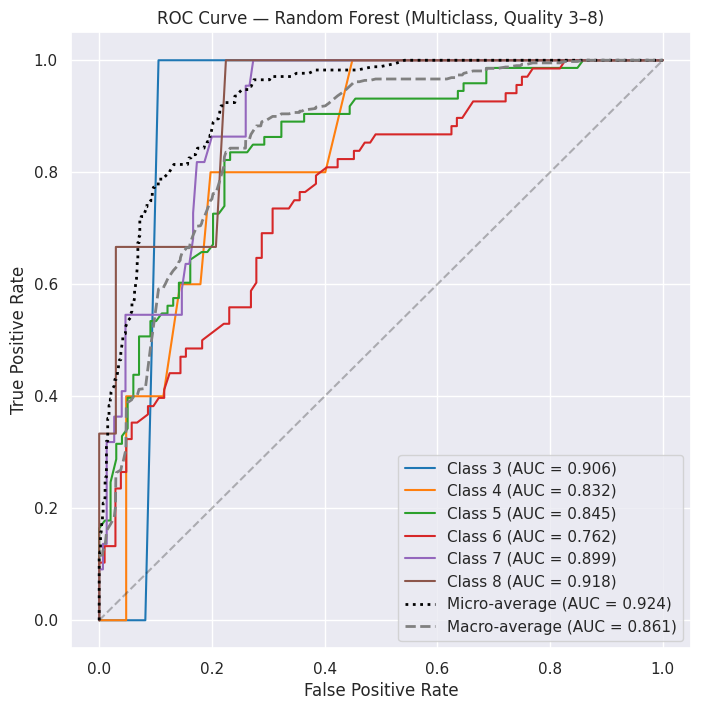

In [2308]:
# --- Pastikan urutan kelas sesuai dengan label asli ---
classes = np.sort(y.unique())
print("Kelas yang digunakan:", classes)

# --- Binarize target sesuai urutan kelas ---
y_test_bin = label_binarize(y_test, classes=classes)

# --- ROC curve untuk tiap kelas ---
fpr = dict()
tpr = dict()
roc_auc = dict()

for i, c in enumerate(classes):
    fpr[i], tpr[i], _ = metrics.roc_curve(y_test_bin[:, i], rf_probs[:, i])
    roc_auc[i] = metrics.auc(fpr[i], tpr[i])

# --- Hitung micro-average dan macro-average ---
# Micro-average menghitung secara keseluruhan (semua kelas sekaligus)
fpr["micro"], tpr["micro"], _ = metrics.roc_curve(
    y_test_bin.ravel(), rf_probs.ravel()
)
roc_auc["micro"] = metrics.auc(fpr["micro"], tpr["micro"])

# Macro-average menghitung rata-rata antar kelas
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(classes)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= len(classes)
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = metrics.auc(fpr["macro"], tpr["macro"])

# --- Plot ROC Curve untuk tiap kelas ---
plt.figure(figsize=(8, 8))
colors = plt.cm.tab10.colors

for i, c in enumerate(classes):
    plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)],
             label=f"Class {c} (AUC = {roc_auc[i]:.3f})")

# Tambahkan garis micro-average & macro-average
plt.plot(fpr["micro"], tpr["micro"],
         label=f"Micro-average (AUC = {roc_auc['micro']:.3f})",
         color="black", linestyle=":", linewidth=2)

plt.plot(fpr["macro"], tpr["macro"],
         label=f"Macro-average (AUC = {roc_auc['macro']:.3f})",
         color="gray", linestyle="--", linewidth=2)

# --- Finalisasi tampilan ---
plt.plot([0, 1], [0, 1], "k--", alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest (Multiclass, Quality 3–8)")
plt.legend(loc="lower right")
plt.show()


Text(0.5, 19.049999999999997, 'Predicted label')

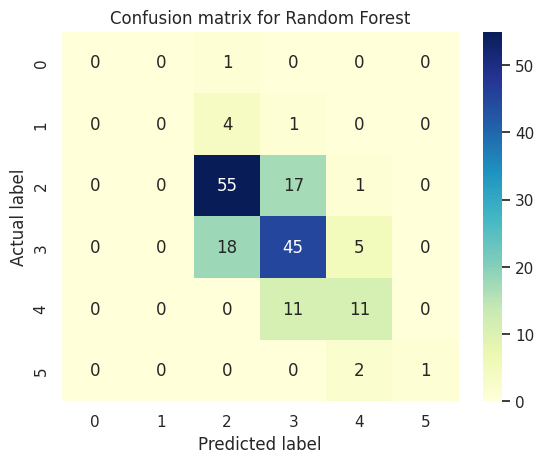

In [2309]:
from sklearn import metrics
cm_rf = confusion_matrix(y_test, random_forest.predict(X_test))
p = sns.heatmap(pd.DataFrame(cm_rf), annot=True, cmap="YlGnBu" ,fmt='g')
plt.title("Confusion matrix for Random Forest")
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [2310]:
# --- 1. Simpan model Random Forest ---
import joblib
joblib.dump(random_forest, 'model_random_forest6.pkl')
print(" Model Random Forest berhasil disimpan sebagai 'model_random_forest6.pkl'")

# --- 2. Membaca data testing ---
import pandas as pd
dataset2 = "/content/data_testing.csv"
testing = pd.read_csv(dataset2)

print("\n Info Data Testing:")
print(testing.info())
display(testing.head())

# --- 3. Load model yang telah disimpan ---
loaded_model = joblib.load('model_random_forest6.pkl')
print("\n Model berhasil dimuat kembali.")

# --- 4. Siapkan data untuk prediksi (hapus kolom non-fitur seperti 'Id') ---
testing_for_prediction = testing.drop(columns=['Id'], errors='ignore')

# --- 5. Lakukan prediksi ---
y_pred = loaded_model.predict(testing_for_prediction)

# --- 6. Gabungkan hasil prediksi dengan kolom 'Id' ---
hasil_prediksi = pd.DataFrame({
    'Id': testing['Id'] if 'Id' in testing.columns else range(1, len(testing) + 1),
    'predicted_quality': y_pred
})

# --- 7. Tampilkan hasil sebelum disimpan ---
print("\n Hasil Prediksi (5 baris pertama):")
display(hasil_prediksi.head())

# --- 8. Simpan hasil ke file Excel ---
hasil_prediksi.to_excel('hasilprediksi_010.xlsx', index=False)
print("Hasil prediksi telah disimpan ke 'hasilprediksi_010.xlsx'")

 Model Random Forest berhasil disimpan sebagai 'model_random_forest6.pkl'

 Info Data Testing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         286 non-null    float64
 1   volatile acidity      286 non-null    float64
 2   citric acid           286 non-null    float64
 3   residual sugar        286 non-null    float64
 4   chlorides             286 non-null    float64
 5   free sulfur dioxide   286 non-null    float64
 6   total sulfur dioxide  286 non-null    float64
 7   density               286 non-null    float64
 8   pH                    286 non-null    float64
 9   sulphates             286 non-null    float64
 10  alcohol               286 non-null    float64
 11  Id                    286 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 26.9 KB
None


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516



 Model berhasil dimuat kembali.

 Hasil Prediksi (5 baris pertama):


,Id,predicted_quality
0,222,5
1,1514,5
2,417,5
3,754,5
4,516,6


Hasil prediksi telah disimpan ke 'hasilprediksi_010.xlsx'
